# HOMEWORK 1

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW1

In [2]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"
#
# # Note. To upload big files to GitHub, execute the next command in the terminal
# # 1. brew install git-lfs
# # 2. git lfs install
# # 3.1. git lfs track "*.safetensors"
# # 3.2. git lfs track "*.bin"

In [3]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input images
hm_version = 1

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone images
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Computer Vision/Practical_tasks/temp'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


Once your environment is set up (see `homework.md` for the three tracks — plain venv, conda, or Colab), this notebook is where you verify it: **complete the blank lines and run every cell top to bottom with no errors.**

Run Jupyter from inside `lesson_1/` so the relative `data/` paths resolve, and select your course kernel (e.g. *Python (cv)*) if prompted.

You will build two collages:
1. a 2×2 collage of the image with its colour channels reordered (RGB, RBG, GRB, BGR);
2. a collage of the image flipped horizontally and vertically.

In [32]:
# Load data

import cv2
import numpy as np
import apps.reporter as rpt
from pathlib import Path
from matplotlib import pyplot as plt

# Input data
file_name = "resources/images/kodim21.png"
# Global config of the picture size
# plt.rcParams['figure.figsize'] = [15, 10]

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

# Convert it to RGB
if img_bgr is not None:
    # Variant 1: using CV
    # img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # Variant 2: reversed slicing
    img_rgb = img_bgr[..., ::-1]
else:
    raise ValueError('Incorrect input data "img_rgb"!')

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(512, 768, 3)"


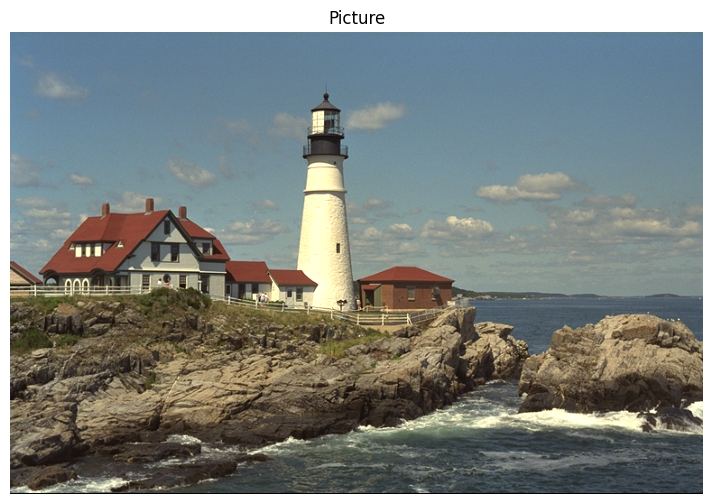

In [34]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis('off')

# Plot it
plt.title("Picture")
plt.show()


Let's make the channel-reorder collage.

In [ ]:
# Split the image into the three colour channels
red, green, blue = cv2.split(img)

# Compose the image in the RGB colour space
img1 = cv2.merge([red, green, blue])

# Compose the image in the RBG colour space
img2 =

# Compose the image in the GRB colour space
img3 =

# Compose the image in the BGR colour space
img4 =

# Create the collage
out1 = np.hstack([img1, img2])
out2 = np.hstack([img3, img4])
out = np.vstack([out1, out2])

# Plot the collage
plt.imshow(out)
plt.axis(False)

Now make a simple geometric collage: flip the image both horizontally and vertically to reproduce the layout below.

![example collage](../data/example.jpg "Expected result")

You can flip the arrays by slicing, or use the numpy helpers [fliplr](https://numpy.org/doc/stable/reference/generated/numpy.fliplr.html) and [flipud](https://numpy.org/doc/stable/reference/generated/numpy.flipud.html) ;-).

In [ ]:
# Load an image (you can freely chose any image you like)
img =
# Convert it to RGB
img =

# Make a collage


# Plot the collage
